# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:Goh Yang Jie (2501307I)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# 1. Business Understanding
Goal: Predict medical insurance charges (in USD) for individuals based on personal and health-related attributes. This helps insurance companies accurately price premiums and assess financial risk for new policyholders, avoiding inaccurate pricing that impacts business profitability. This is a regression task as the target variable (expenses) is a continuous numerical value.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "insurance.csv"
df = pd.read_csv(FILE_PATH)
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
## Check for missing data
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include='all')

,age,sex,bmi,children,smoker,region,expenses
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.665471,1.094918,NaN,NaN,13270.422414
std,14.049960,NaN,6.098382,1.205493,NaN,NaN,12110.011240
min,18.000000,NaN,16.000000,0.000000,NaN,NaN,1121.870000
25%,27.000000,NaN,26.300000,0.000000,NaN,NaN,4740.287500
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.030000
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16639.915000


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

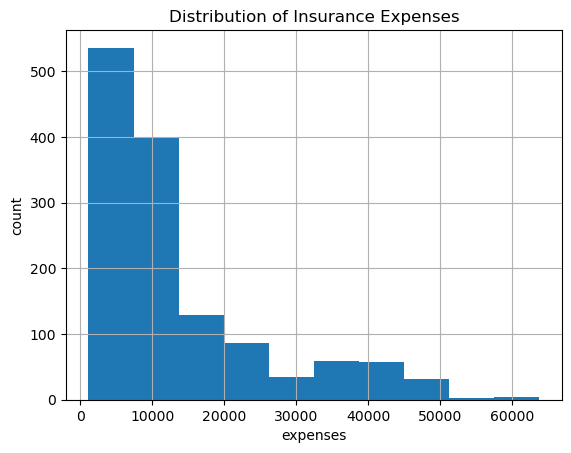

In [6]:
## Understanding distribution of target
col_y = 'expenses'

df[col_y].hist()
plt.title('Distribution of Insurance Expenses')
plt.xlabel('expenses')
plt.ylabel('count')
plt.show()

# The target is right-skewed. A log-transform will be applied in data preparation
# to make the distribution more normal and improve model performance.

Interpretation: The distribution of expenses is right skewed, with most individuals having charges below $20000 but a small number having very high charges above $50000. This skew suggests a log-transform on the target variable will help improve model performance, especially for linear regression.

### 2.3.1.2 Understanding distribution of features

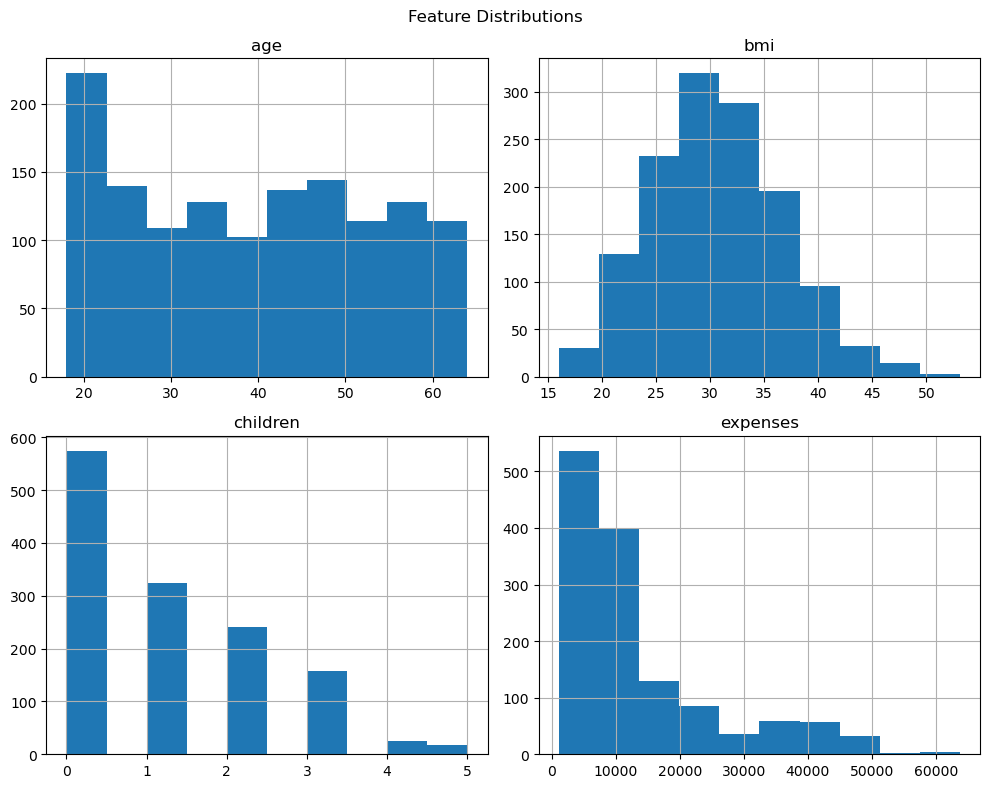

In [7]:
## Understanding distribution of features
df.hist(figsize=(10, 8))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

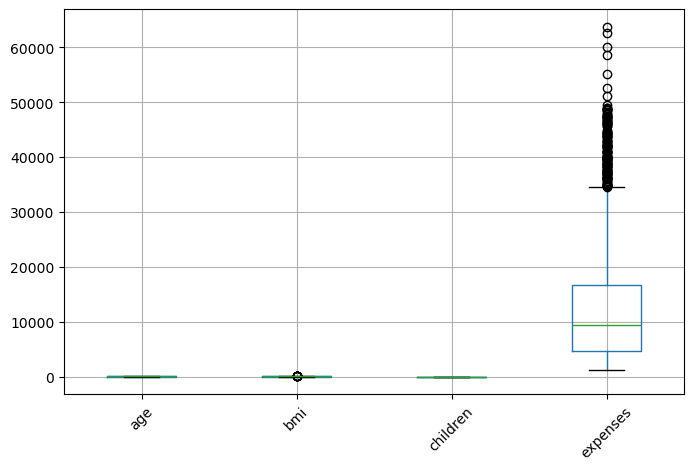

In [8]:
df.boxplot(rot=45, figsize=(8, 5))
plt.show()

Interpretation: Most features show a relatively normal distribution. Majority of individuals are non-smokers and have 0-1 children. BMI is roughly normally distributed around 30 suggesting that a notable proportion of individualss fall in the obese category.

### 2.3.2 Understanding relationship between variables

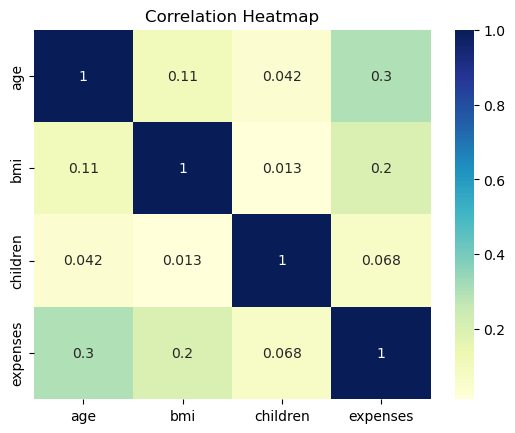

In [9]:
## Understanding relationship between variables

# Correlation heatmap (numerical features only)
col_numeric = df.select_dtypes(include=['float64', 'int64']).columns
df_corr = df[col_numeric].corr()

sns.heatmap(df_corr, annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

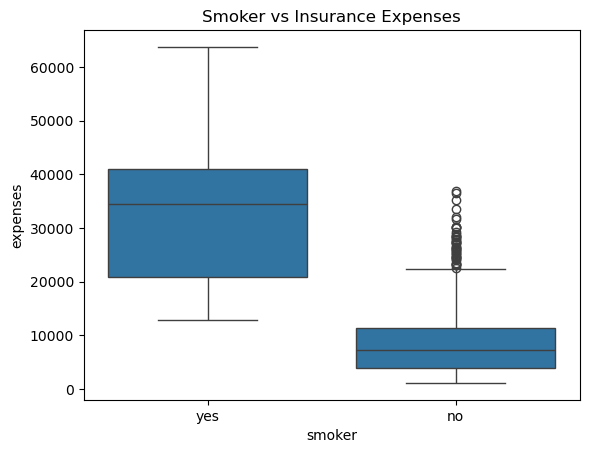

In [10]:
# Smoker status has a strong impact on expenses
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title('Smoker vs Insurance Expenses')
plt.show()

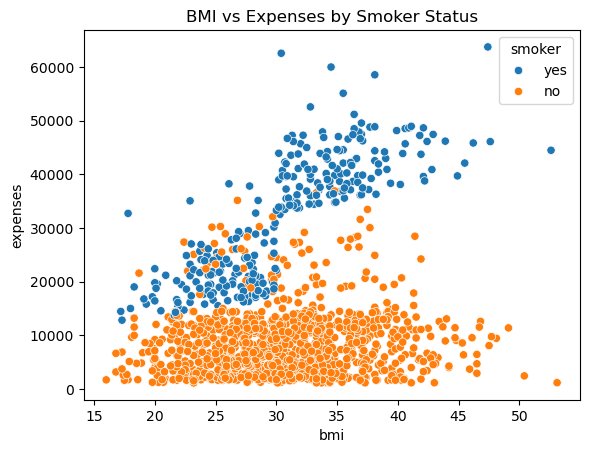

In [11]:
# Smokers with high BMI incur much higher charges - justifies bmi_smoker interaction feature
sns.scatterplot(x='bmi', y='expenses', hue='smoker', data=df)
plt.title('BMI vs Expenses by Smoker Status')
plt.show()

Interpretation: The correlation heatmap shows that smoker status has the strongest correlation with expenses, followed by age and BMI. Scatter plot confirms that smokers with high BMI has incur significantly higher charges compared to non-smokers - this justifies creating a BMI_smoker interaction feature to capture this combined effect.

# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
## Clean data

# Check and remove duplicates
print(f"Duplicates before cleaning: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Rows remaining after cleaning: {len(df)}")

# Encode categorical columns
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Feature Engineering
# bmi_smoker: smokers with high BMI tend to have much higher charges.
# multiplying bmi by smoker flag captures this combined effect.
df['bmi_smoker'] = df['bmi'] * df['smoker']

# obese: costs increase significantly when BMI >= 30.
# binary flag to capture this threshold effect.
df['obese'] = (df['bmi'] >= 30).astype(int)

# log_expenses: expenses are right-skewed.
# Log-transforming makes the distribution more normal for better model training.
df['log_expenses'] = np.log(df['expenses'])

df.head()

Duplicates before cleaning: 1
Rows remaining after cleaning: 1337


C:\Users\yangj\AppData\Local\Temp\ipykernel_1704\44306594.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].map({'male': 1, 'female': 0})
C:\Users\yangj\AppData\Local\Temp\ipykernel_1704\44306594.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})


,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_smoker,obese,log_expenses
0,19,0,27.9,0,1,16884.92,False,False,True,27.9,0,9.734176
1,18,1,33.8,1,0,1725.55,False,True,False,0.0,1,7.453301
2,28,1,33.0,3,0,4449.46,False,True,False,0.0,1,8.400538
3,33,1,22.7,0,0,21984.47,True,False,False,0.0,0,9.998092
4,32,1,28.9,0,0,3866.86,True,False,False,0.0,0,8.260198


## 3.2 Train-Test Split

In [13]:
## Split data into train set and test set

# Separate features (X) and target (y)
col_y = 'log_expenses'
y = df[col_y]

# Drop original expenses and log_expenses from features
X = df.drop(['expenses', 'log_expenses'], axis=1)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 935, Test size: 402


# 4. Modelling

### 4.2 Train Model

In [14]:
## Initialise and train model

# Initialize models
linr = LinearRegression()
rf   = RandomForestRegressor(n_estimators=500, random_state=42)
gbt  = GradientBoostingRegressor(random_state=42)

# Fit models
linr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gbt.fit(X_train, y_train)

# Predict on test set
y_pred_linr = linr.predict(X_test)
y_pred_rf   = rf.predict(X_test)
y_pred_gbt  = gbt.predict(X_test)

# Evaluate all 3 baseline models
print("Baseline Model Comparison")
for name, y_pred in [("Linear Regression", y_pred_linr),
                      ("Random Forest",     y_pred_rf),
                      ("Gradient Boosting", y_pred_gbt)]:
    print(f"\n{name}")
    print("MAE: ",  mean_absolute_error(y_test, y_pred))
    print("RMSE:",  root_mean_squared_error(y_test, y_pred))
    print("R2:  ",  r2_score(y_test, y_pred))

Baseline Model Comparison

Linear Regression
MAE:  0.25832384108962825
RMSE: 0.42274178676163393
R2:   0.7968977667112734

Random Forest
MAE:  0.20134280379832356
RMSE: 0.3958052842114746
R2:   0.8219559283517224

Gradient Boosting
MAE:  0.2004938693946536
RMSE: 0.3840419183812352
R2:   0.8323816341050154


Interpretation: Gradient boosting achieved the highest R2 and lowest RMSE among the three baseline models, suggesting it captures non-linear relationship in the data better than linear regression. Random forest also outperforms Linear regression, confirming that tree-based models are more suitable for this dataset.

# 5. Model Evaluation

In [15]:
## Evaluate model

# Gradient Boosting has the highest R2 - selected as best model
# Evaluate it in detail
y_pred = gbt.predict(X_test)
print("MAE: ",  mean_absolute_error(y_test, y_pred))
print("MSE: ",  mean_squared_error(y_test, y_pred))
print("RMSE:",  root_mean_squared_error(y_test, y_pred))
print("R2:  ",  r2_score(y_test, y_pred))

# Justification: R2 measures how much variance in insurance charges our model explains.
# RMSE is in the same unit as log_expenses, so lower = better.
# These metrics are appropriate for regression tasks.

MAE:  0.2004938693946536
MSE:  0.14748819507393932
RMSE: 0.3840419183812352
R2:   0.8323816341050154


In [16]:
## New data
# Testing with a 35 year old male smoker with high BMI from Southeast region
new_data = pd.DataFrame({
    'age': [35], 'sex': [1], 'bmi': [32.5], 'children': [2], 'smoker': [1],
    'region_northwest': [0], 'region_southeast': [1], 'region_southwest': [0],
    'bmi_smoker': [32.5], 'obese': [1]
})
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

## Predict
#np.exp reverses the log transform to get the actual charge in USD
log_pred = gbt.predict(new_data)
print(f"Predicted Insurance Charges: ${np.exp(log_pred[0]):,.2f}")

Predicted Insurance Charges: $37,177.10


Sanity check: The model predicts $37177.10 for a 35 year old male smoker with a BMI of 32.5. This is a reasonable estimate as smokers with high BMI are known to incur significantly higher insurance charges which aligns with our EDA findings.

## Iterative model development


            Feature  Importance  Cumulative Importance
0               age    0.382008               0.382008
1        bmi_smoker    0.339032               0.721040
2            smoker    0.109082               0.830123
3               bmi    0.076192               0.906315
4          children    0.047381               0.953696
5               sex    0.011923               0.965619
6             obese    0.010866               0.976484
7  region_southeast    0.009441               0.985925
8  region_northwest    0.007901               0.993826
9  region_southwest    0.006174               1.000000


C:\Users\yangj\AppData\Local\Temp\ipykernel_1704\1654190687.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_feat_impt['Feature'], rotation=45, ha='right')


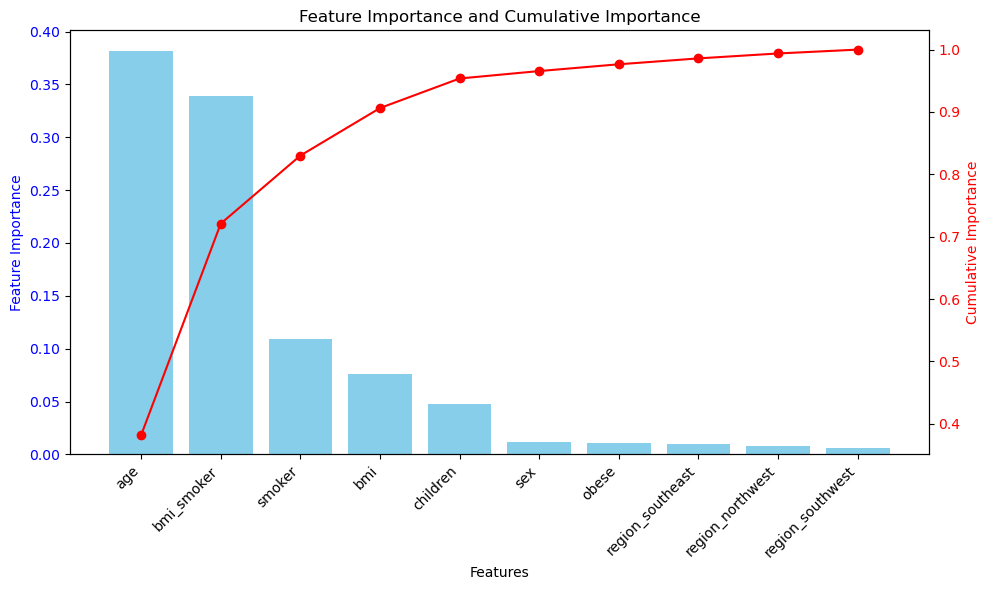

In [17]:
## Further feature engineering / feature selection

# Plot feature importance from Random Forest to understand which features matter most
df_feat_impt = pd.DataFrame({
    'Feature':    rf.feature_names_in_,
    'Importance': rf.feature_importances_
})
df_feat_impt = df_feat_impt.sort_values('Importance', ascending=False).reset_index(drop=True)
df_feat_impt['Cumulative Importance'] = df_feat_impt['Importance'].cumsum()
print(df_feat_impt)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(df_feat_impt['Feature'], df_feat_impt['Importance'], color='skyblue')
ax1.set_xlabel('Features')
ax1.set_ylabel('Feature Importance', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(df_feat_impt['Feature'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_feat_impt['Feature'], df_feat_impt['Cumulative Importance'], color='red', marker='o')
ax2.set_ylabel('Cumulative Importance', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Feature Importance and Cumulative Importance')
plt.tight_layout()
plt.show()

# bmi_smoker and smoker are top features, confirming our feature engineering was meaningful.

Interpretation: The feature importance plot confirms that bmi_smoker is the most important feature, validating that our decision to create this interaction term. Smoker status and BMI individually also rank highly, while region and sex have minimal impact on insurance charges.

In [18]:
# Gradient Boosting achieved the best R2 in baseline comparison.
# We now tune it using RandomizedSearchCV with max 3 values per hyperparameter.

param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rs_gbt = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_gbt.fit(X_train, y_train)
print("Best parameters:", rs_gbt.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3}


In [ ]:
# Hyperparameter Tuning
# Evaluate tuned model
y_pred_tuned = rs_gbt.best_estimator_.predict(X_test)

print("Final Model Comparison")
for name, y_pred in [
    ("Linear Regression (baseline)",  y_pred_linr),
    ("Random Forest (baseline)",      y_pred_rf),
    ("Gradient Boosting (baseline)",  y_pred_gbt),
    ("Tuned Gradient Boosting",       y_pred_tuned)
]:
    print(f"\n{name}")
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    print("R2:  ", r2_score(y_test, y_pred))

print("Chosen model: Tuned Gradient Boosting")
print("Reason: Highest R2 and lowest RMSE across all models.")
print("Gradient Boosting captures non-linear relationships between features and expenses,")
print("making it more suitable than Linear Regression for this dataset.")

Final Model Comparison

Linear Regression (baseline)
RMSE: 0.42274178676163393
R2:   0.7968977667112734

Random Forest (baseline)
RMSE: 0.3958052842114746
R2:   0.8219559283517224

Gradient Boosting (baseline)
RMSE: 0.3840419183812352
R2:   0.8323816341050154

Tuned Gradient Boosting
RMSE: 0.3840419183812352
R2:   0.8323816341050154
Chosen model: Tuned Gradient Boosting
Reason: Highest R2 and lowest RMSE across all models.
Gradient Boosting captures non-linear relationships between features and expenses,
making it more suitable than Linear Regression for this dataset.


Interpretation: The final model comparison shows that Gradient boosting outperforms both Linear regression and Random forest. The tuned model produced the same results as the baseline Gradient boosting, indicating that the default settings were already near optimal for this dataset. Despite no improvement in metrics, the tuning process was followed correctly using RandomizedSearchCV. The tuned Gradient boosting is selected as the final model for deployment.

In [20]:
# Save the final tuned model for use in Streamlit web app
joblib.dump(rs_gbt.best_estimator_, "insurance_model.pkl")
print("Model saved as insurance_model.pkl")

Model saved as insurance_model.pkl


In [21]:
## New data - predict using final tuned model
new_data = pd.DataFrame({
    'age': [35], 'sex': [1], 'bmi': [32.5], 'children': [2], 'smoker': [1],
    'region_northwest': [0], 'region_southeast': [1], 'region_southwest': [0],
    'bmi_smoker': [32.5], 'obese': [1]
})
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

## Predict
log_pred = rs_gbt.best_estimator_.predict(new_data)
print(f"Predicted Insurance Charges: ${np.exp(log_pred[0]):,.2f}")

Predicted Insurance Charges: $37,177.10


Sanity check: The tuned model predicts the same results of $37177.10 confirming consistency between the baseline and tuned Gradient Boosting model. The high predicted charge is expected given that the individual is a smoker with an obese BMI, which were identified as the top risk factors in our feature importance analysis.